# Round 0 Data Exploration
Basic exploration of prices and trades data across day -2 and day -1.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.concat([
    pd.read_csv('data/prices_round_0_day_-2.csv', sep=';'),
    pd.read_csv('data/prices_round_0_day_-1.csv', sep=';'),
], ignore_index=True)

print('Prices shape:', prices.shape)
prices.head()

Prices shape: (40000, 17)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0


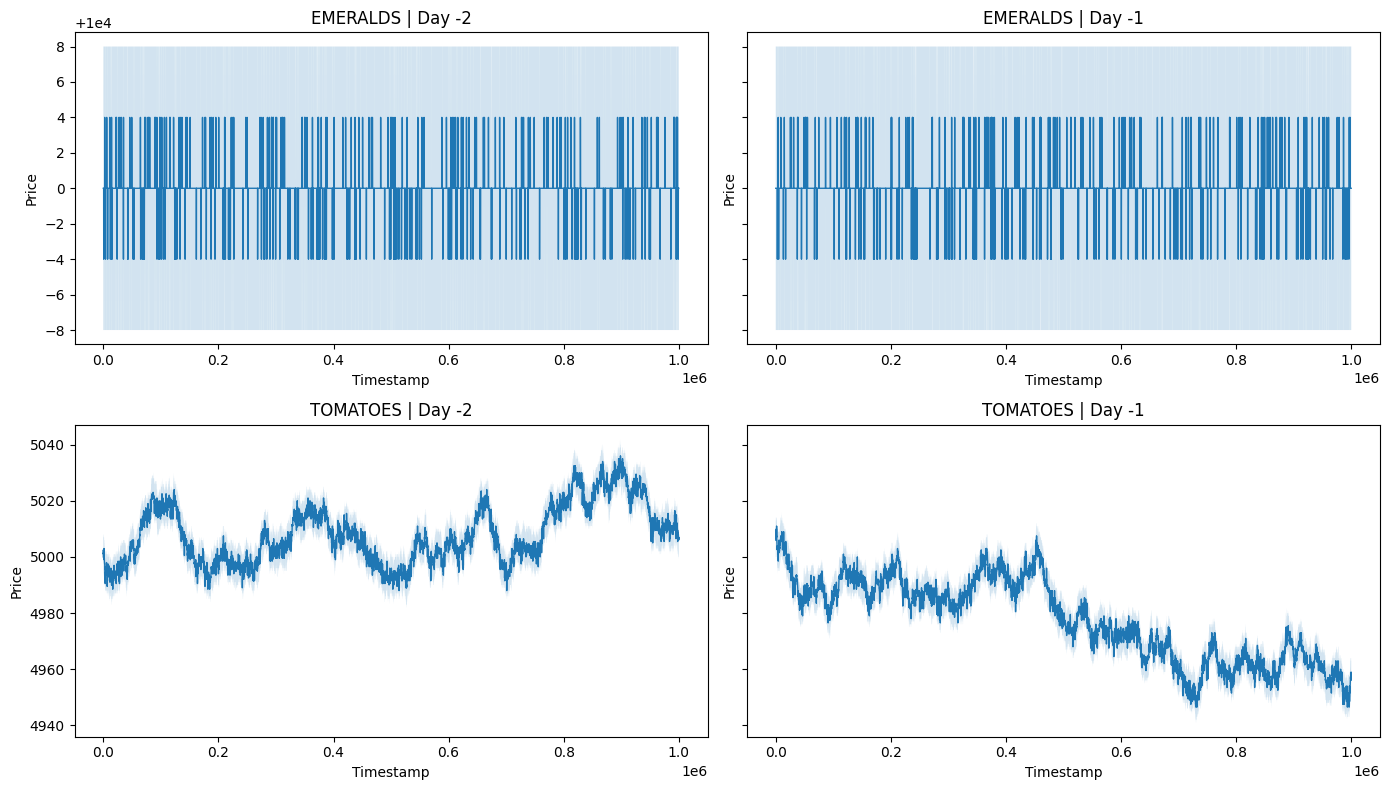

In [30]:
products = prices['product'].unique()
days = sorted(prices['day'].unique())

fig, axes = plt.subplots(len(products), len(days), figsize=(14, 4 * len(products)), sharey='row')
if len(products) == 1:
    axes = [axes]

for r, product in enumerate(products):
    for c, day in enumerate(days):
        ax = axes[r][c]
        subset = prices[(prices['product'] == product) & (prices['day'] == day)]
        ax.plot(subset['timestamp'], subset['mid_price'], lw=1)
        ax.fill_between(subset['timestamp'], subset['bid_price_1'], subset['ask_price_1'], alpha=0.2)
        ax.set_title(f'{product} | Day {day}')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

## Tomatoes — Mean Reversion Analysis

ADF test on TOMATOES mid_price (constant, no lags):
  t-statistic = -4.6407
  Critical values: 1%=-3.43, 5%=-2.86, 10%=-2.57
  → STATIONARY at 1% level (mean-reverting)

Mean-reversion half-life: 311.2 ticks  (β=-0.002228)


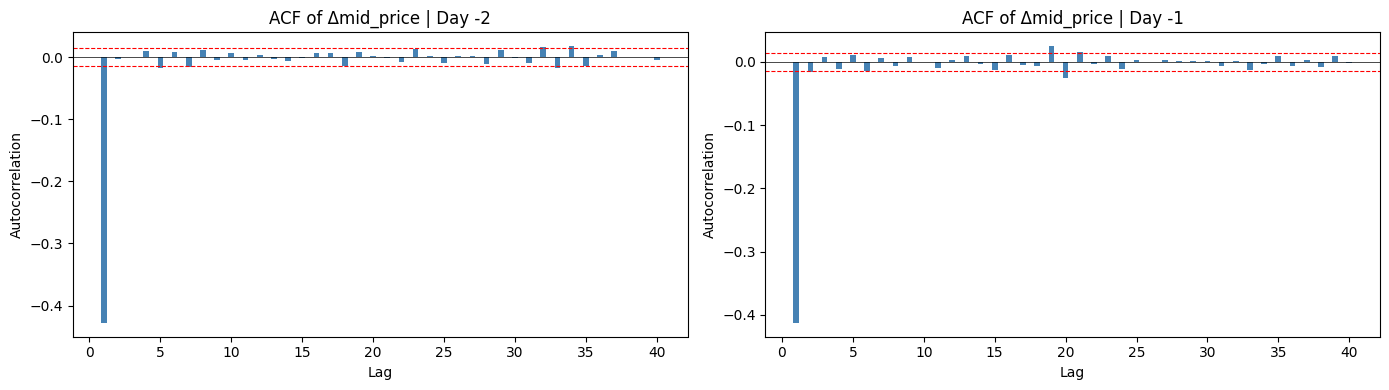

In [31]:
import numpy as np
from scipy import stats

tomatoes = prices[prices['product'] == 'TOMATOES'].copy().reset_index(drop=True)
tomatoes['price_change'] = tomatoes['mid_price'].diff()

p = tomatoes['mid_price'].dropna().values
dp = np.diff(p)

# --- ADF test (no lags, constant only): regress Δp_t = α + β*p_{t-1}
# H0: β = 0 (unit root / random walk). Reject if t-stat < critical value.
# MacKinnon (1994) critical values for large N, constant only: 1%=-3.43, 5%=-2.86, 10%=-2.57
X = np.column_stack([np.ones(len(dp)), p[:-1]])
beta, resid, _, _ = np.linalg.lstsq(X, dp, rcond=None)
fitted = X @ beta
resid = dp - fitted
s2 = resid @ resid / (len(dp) - X.shape[1])
cov = s2 * np.linalg.inv(X.T @ X)
se_beta = np.sqrt(np.diag(cov))
adf_stat = beta[1] / se_beta[1]

# Approximate p-value using MacKinnon response surface (rough interpolation)
# Critical values at 1%, 5%, 10% for model with constant, large N
cv = {1: -3.43, 5: -2.86, 10: -2.57}
sig = "non-stationary (random walk)"
for pct, threshold in sorted(cv.items()):
    if adf_stat < threshold:
        sig = f"STATIONARY at {pct}% level (mean-reverting)"
        break

print("ADF test on TOMATOES mid_price (constant, no lags):")
print(f"  t-statistic = {adf_stat:.4f}")
print(f"  Critical values: 1%={cv[1]}, 5%={cv[5]}, 10%={cv[10]}")
print(f"  → {sig}")

# --- Half-life of mean reversion: half_life = -log(2) / β
half_life = -np.log(2) / beta[1] if beta[1] < 0 else np.inf
print(f"\nMean-reversion half-life: {half_life:.1f} ticks  (β={beta[1]:.6f})")

# --- ACF of price changes (manual, no statsmodels)
def acf(x, nlags=40):
    x = x - x.mean()
    n = len(x)
    var = x @ x / n
    return np.array([1.0] + [(x[:-k] @ x[k:]) / (n * var) for k in range(1, nlags + 1)])

conf = 1.96 / np.sqrt(len(dp))  # 95% confidence band

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, day in zip(axes, sorted(tomatoes['day'].unique())):
    sub = tomatoes[tomatoes['day'] == day]['price_change'].dropna().values
    lags = np.arange(1, 41)
    ac = acf(sub)[1:]  # drop lag 0
    ax.bar(lags, ac, width=0.4, color='steelblue')
    ax.axhline( conf, color='r', linestyle='--', lw=0.8)
    ax.axhline(-conf, color='r', linestyle='--', lw=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'ACF of Δmid_price | Day {day}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


### Linear model — predict next mid price from lagged prices

Linear model (lags=5) — predicting % price change
  Train  MAE=0.01592%  R²=0.2438
  Test   MAE=0.01598%  R²=0.2269
  Naive (predict 0)  MAE=0.01579%  R²=-0.0000

  Coefficients: {'lag_1': np.float64(-0.5665), 'lag_2': np.float64(-0.3235), 'lag_3': np.float64(-0.18), 'lag_4': np.float64(-0.0908), 'lag_5': np.float64(-0.0522)}
  Intercept: 0.000032


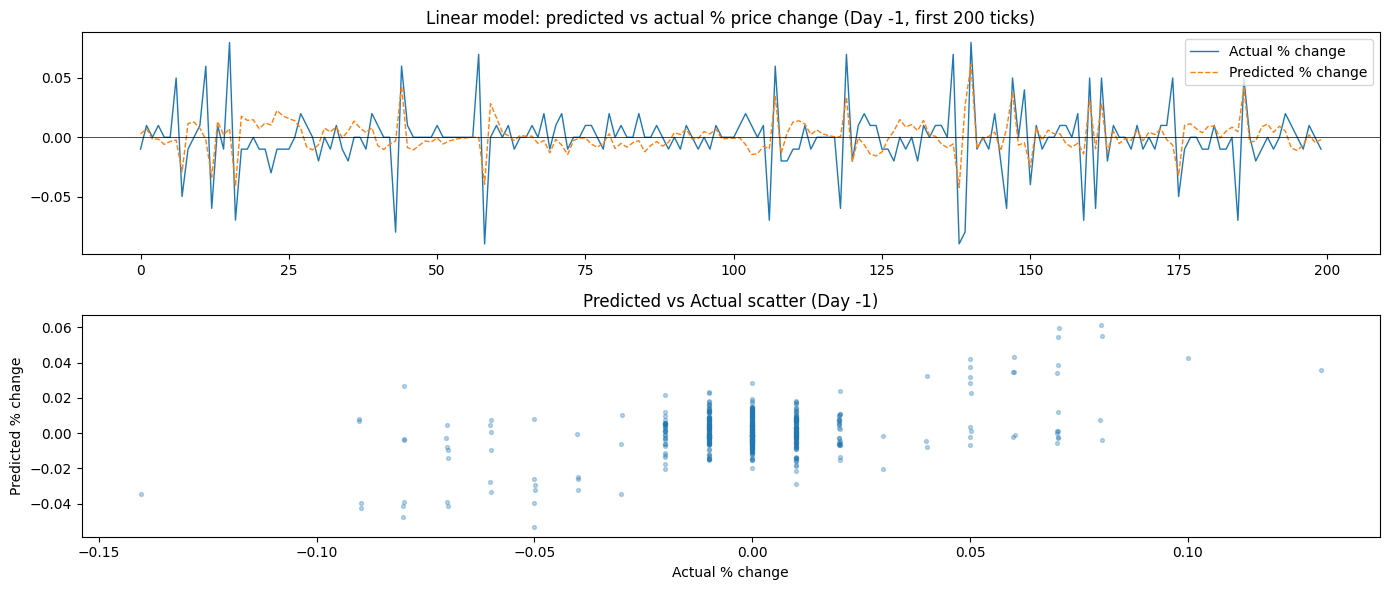

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

LAGS = 5

# Work in percent change space
tomatoes['pct_change'] = tomatoes['mid_price'].pct_change() * 100  # in %

feat = pd.DataFrame({f'lag_{i}': tomatoes['pct_change'].shift(i) for i in range(1, LAGS + 1)})
feat['target'] = tomatoes['pct_change']
feat['day'] = tomatoes['day']
feat = feat.dropna()

train = feat[feat['day'] == -2]
test  = feat[feat['day'] == -1]

feature_cols = [f'lag_{i}' for i in range(1, LAGS + 1)]
lr = LinearRegression()
lr.fit(train[feature_cols], train['target'])

pred_train = lr.predict(train[feature_cols])
pred_test  = lr.predict(test[feature_cols])

# Naive baseline in return space: predict 0 change
naive_pred = np.zeros(len(test))
naive_mae = mean_absolute_error(test['target'], naive_pred)
naive_r2  = r2_score(test['target'], naive_pred)

print(f"Linear model (lags={LAGS}) — predicting % price change")
print(f"  Train  MAE={mean_absolute_error(train['target'], pred_train):.5f}%  R²={r2_score(train['target'], pred_train):.4f}")
print(f"  Test   MAE={mean_absolute_error(test['target'],  pred_test):.5f}%  R²={r2_score(test['target'],  pred_test):.4f}")
print(f"  Naive (predict 0)  MAE={naive_mae:.5f}%  R²={naive_r2:.4f}")
print(f"\n  Coefficients: {dict(zip(feature_cols, lr.coef_.round(4)))}")
print(f"  Intercept: {lr.intercept_:.6f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
idx = range(min(200, len(test)))
axes[0].plot(list(idx), test['target'].values[:200], label='Actual % change', lw=1)
axes[0].plot(list(idx), pred_test[:200], label='Predicted % change', lw=1, linestyle='--')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Linear model: predicted vs actual % price change (Day -1, first 200 ticks)')
axes[0].legend()

axes[1].scatter(test['target'].values[:500], pred_test[:500], alpha=0.3, s=8)
axes[1].set_xlabel('Actual % change')
axes[1].set_ylabel('Predicted % change')
axes[1].set_title('Predicted vs Actual scatter (Day -1)')
plt.tight_layout()
plt.show()


### EWMA model — exponentially weighted moving average as fair value estimate

EWMA model: y = k * ewma(halflife=λ)
     λ         k   Train MAE    Test MAE   Test R²
--------------------------------------------------
   0.5   -0.6822     0.01596     0.01599    0.2045
     1   -1.1289     0.01589     0.01595    0.2267
     2   -1.8769     0.01598     0.01609    0.2215
     5   -3.1460     0.01640     0.01654    0.1700
    10   -3.4161     0.01646     0.01653    0.1129
    20   -2.1369     0.01632     0.01620    0.0480
    50   -0.5407     0.01598     0.01588    0.0059
   100   -0.1593     0.01589     0.01581    0.0009

Naive (predict 0)  MAE=0.01579%
Best halflife: 100  k=-0.1593


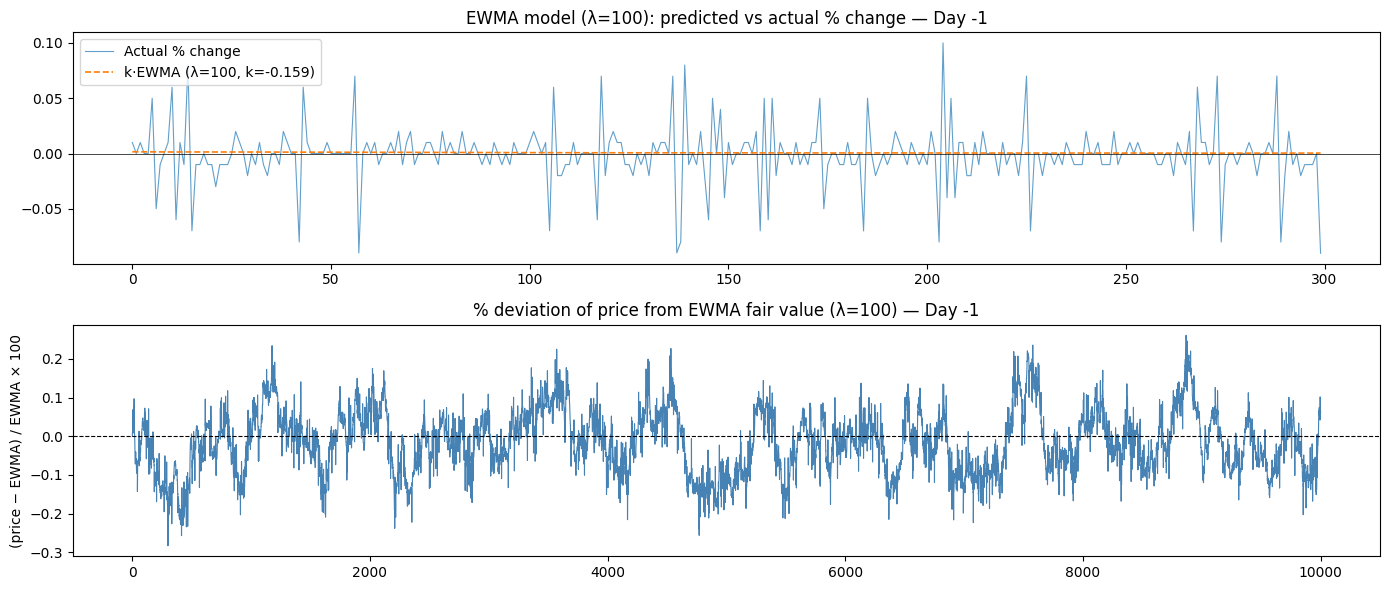

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

halflives = [0.5, 1, 2, 5, 10, 20, 50, 100]

train_ret = tomatoes[tomatoes['day'] == -2]['pct_change'].dropna().reset_index(drop=True)
test_ret  = tomatoes[tomatoes['day'] == -1]['pct_change'].dropna().reset_index(drop=True)

def make_xy(ret, hl):
    ewma = ret.ewm(halflife=hl, adjust=False).mean().shift(1)
    df = pd.concat([ewma.rename('ewma'), ret.rename('y')], axis=1).dropna()
    return df['ewma'].values, df['y'].values

print("EWMA model: y = k * ewma(halflife=λ)")
print(f"{'λ':>6}  {'k':>8}  {'Train MAE':>10}  {'Test MAE':>10}  {'Test R²':>8}")
print("-" * 50)

results = {}
for hl in halflives:
    x_tr, y_tr = make_xy(train_ret, hl)
    x_te, y_te = make_xy(test_ret,  hl)

    # OLS through origin: k = (x · y) / (x · x)
    k = (x_tr @ y_tr) / (x_tr @ x_tr)

    train_mae = mean_absolute_error(y_tr, k * x_tr)
    test_mae  = mean_absolute_error(y_te, k * x_te)
    test_r2   = r2_score(y_te, k * x_te)
    results[hl] = (test_mae, k, x_te, y_te)

    print(f"{hl:>6}  {k:>8.4f}  {train_mae:>10.5f}  {test_mae:>10.5f}  {test_r2:>8.4f}")

naive_mae = mean_absolute_error(test_ret.iloc[1:], np.zeros(len(test_ret) - 1))
print(f"\nNaive (predict 0)  MAE={naive_mae:.5f}%")

best_hl = min(results, key=lambda hl: results[hl][0])
_, best_k, best_x, best_y = results[best_hl]
print(f"Best halflife: {best_hl}  k={best_k:.4f}")

# Plot
test_prices = tomatoes[tomatoes['day'] == -1]['mid_price'].reset_index(drop=True)
ewma_level  = test_prices.ewm(halflife=best_hl, adjust=False).mean()
pct_dev     = (test_prices - ewma_level) / ewma_level * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
n = min(300, len(best_y))
axes[0].plot(range(n), best_y[:n], label='Actual % change', lw=0.8, alpha=0.7)
axes[0].plot(range(n), (best_k * best_x)[:n], label=f'k·EWMA (λ={best_hl}, k={best_k:.3f})', lw=1.2, linestyle='--')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title(f'EWMA model (λ={best_hl}): predicted vs actual % change — Day -1')
axes[0].legend()

axes[1].plot(pct_dev.values, lw=0.8, color='steelblue')
axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
axes[1].set_title(f'% deviation of price from EWMA fair value (λ={best_hl}) — Day -1')
axes[1].set_ylabel('(price − EWMA) / EWMA × 100')
plt.tight_layout()
plt.show()
